In [1]:
import requests
import json
import pandas as pd
import requests
import json



##### But what is an ML Engineer, exactly?
💡 It's a new role that is emerging as data jobs specialize


<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/dajuca/ML_Pictures/refs/heads/main/Figure2-514e275cca0a0450485a49c805aeb321.png" width="40%">
</div>

<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/dajuca/ML_Pictures/refs/heads/main/Figure3-7c5de9f92f3406e23d76e6bff3f89818.png" width="40%">
</div>




💡 It's also emerging as tools become more mature

🤯 The full modern ML stack is way too big to cover in this bootcamp (source)


<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/dajuca/ML_Pictures/refs/heads/main/ML%20architecture.png" width="80%">
</div>

# Train at Scale # 
## 1) Packaging & Virtual Env 101
### 1.1) What is a Package?


👉 Re-usable code from one project to another (from ... import ...)

A package allows you to:

👉 Share it with others

- Install from [PyPI](https://pypi.org/): pip install <package_name>
- Install from GitHub: pip install git+https://...
👉 Deploy in production (on Linux servers)

👉 Track code (git) and collaborate on it!

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/data-engineering/01_min_package.png" >

- A module is a single python file inside a package
- A package is directory of python modules that contains an additional __init__.py

👉 `__init__.py` allows you to write toto.lib, for instance


```sh
    # CLI (Command Line Interface)
    python -m toto.lib  # Executes as a module
    python toto/lib.py  # Executes as a file



```python 
    from toto.lib import a_function
```

👉 `__init__.py` s content (often empty) is executed at each import line


### Mac users



```sh

    mkdir project-toto
    cd project-toto
    mkdir toto
    touch toto/lib.py
    touch toto/__init__.py
    touch setup.py
    code .
```

```python 

    # toto/lib.py
    def who_am_i():
        print("Hello my name is Jean")
    if __name__ == '__main__':
        who_am_i()
```

<!-- 
### Windows users

```sh

mkdir project-toto
cd project-toto
mkdir toto
type nul > toto\lib.py
type nul > toto\__init__.py
type nul > setup.py
code . -->


### 1.2) Virtual environments

💻 **Let's create a dedicated virtual env totoenv for this project**

💡 One `venv` per project is a good practice!

```sh 
    # Create new totoenv inside python 3.8.12
    pyenv virtualenv 3.8.12 totoenv

    # In project-toto, create `.python-version` that activates totoenv when present 
    pyenv local totoenv


```



```sh
    #If linux 
    ## Sometines it needs a hard activate when in root (linux)
    source $(pyenv root)/versions/totoenv3/bin/activate

    ## Option 2 iF executed not as root 

    su - User (replace with your environment user)

    ## change python version ownership as your user if not executed as root

    sudo chown juan:juan .python-version
```

In [2]:
# sudo chown -R juan:juan /home/juan/Business_data_management/Day01/project-toto GIVE PERMISSIONS TO THE FOLDER

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/Screenshot%202022-05-18%20at%2016.37.03.png" width='100%'>

**Install minimal packages for this demo lecture**

```sh 

pip list
pip install --upgrade pip

pip install pandas
pip install ipython   # needed for ipython
pip install ipykernel # needed for notebooks
```

**Reminder on pyenv vs. venv**

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/data-engineering/python_virtual_envs.png" width='100%'> 

### **2) 💻 Installing & Using a Package**

🎯 Goals

`pip install` `toto` in virtual env `totoenv`


### 2.1) Install the Package

**Fill in `setup.py`**

```python
# setup.py
from setuptools import setup

setup(name='toto',
      description="package description",
      packages=["toto"]) # You can have several packages, try it
```

**Install**

Sit next to `setup.py` and run:

```sh
pip install .
```

### 2.2) Run the Package from Anywhere (when totoenv is Activated)


**For instance, from a notebook**?



```sh
mkdir notebooks
touch notebooks/notebook.ipynb
```

Open the notebook with VS Code, select `ipykernel=totoenv`, and you should be able to call

```python
from toto.lib import who_am_i
who_am_i()
```

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/totoenv-notebook.png" width='100%'> 

❓ **Why Does it Work?**

🔎 Well, remember that Python's import always looks at your PYTHONPATH

```python

import sys
sys.path
```

Which pyenv always appends with site-packages:

👉 ~/.pyenv/versions/3.8.12/envs/**totoenv**/lib/python3.8/**site-packages**

✅ pip install . creates a **COPY** of your project folder inside <span style="color: blue;">site-packages</span>



<span style="color: blue;">site-packages</span> contains all your pip packages.



🔎 Use it to explore third-party libraries!



<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/Pasted_Image_18_05_2022_16_30.png" width='90%'> 

🔥 Hot-Reload on the Package?

```python

def who_am_i():

    print("Hello my name is Jean UPDATED")
```

👉 Is the modification visible?

❌ No, because pip install . only creates a **COPY** of your project in site-packages

✅ `pip install -e .` (editable) for hot-reloading
- First, pip uninstall toto (move away from setup.py's root to do it properly)
- Then pip install -e .



```python
import toto
toto.__file__ # '~/code/sandbox/project-toto/toto/__init__.py'
```

PS.: for notebooks and `ipython`, don't forget the magic command to avoid closing/reopening `ipython` every time

In [3]:
%load_ext autoreload
%autoreload 2

### 2.3) Dependencies

👉 Let's say we want the `pandas` package to be installed along with `toto`

```python
# toto/lib.py

import pandas as pd

def simple_df():
    df = pd.DataFrame([['Alice', 25], ['Bob', 30]], columns=['Name', 'Age'])
    return df
```

✅ Solution: create `requirements.txt` and update `setup.py`

```sh

# Terminal
touch requirements.txt
echo pandas >> requirements.txt
```

...or specify the version to be used (`pandas==1.1.0`, for example)

```python
# setup.py
from setuptools import setup
from setuptools import find_packages

# list dependencies from file
with open('requirements.txt') as f:
    content = f.readlines()
requirements = [x.strip() for x in content]

setup(name='toto',
      description="package description",
      packages=find_packages(), # NEW: find packages automatically
      install_requires=requirements) # NEW
```

🏁 Then, **pip install -e** . to update `totoenv` with `requirements.txt`


<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/Screenshot%202022-05-19%20at%2009.16.57.png" width='80%'> 

**2.4) Adding a Makefile to Create Simple CLI Commands ⚡️**

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/Screenshot%202022-05-19%20at%2009.19.59.png" width='80%'> 

**Makefile Sample**

`Makefile`



```python
directive_name:
<tab>some command with all its arguments
<tab>@this command will not print out before being executed
<tab>-the command after this one will run no matter what
<tab>-@the markers can be combined
```

**A Simple Makefile**

```python
install:
    @pip install -e .

clean:
    @rm -f */version.txt
    @rm -f .coverage
    @rm -f */.ipynb_checkpoints
    @rm -Rf build
    @rm -Rf */__pycache__
    @rm -Rf */*.pyc
    
all: install clean


💻 Let's run a directive; while sitting next to the `Makefile`:


```sh
tree
make clean
tree
```

Let's run several directives; while sitting next to the `Makefile`:



❗️ The Makefile is highly sensitive:
- Its name is case-sensitive; call it `makefile` and nothing works
- The commands inside of the directives must be indented exclusively using **tabulations**; use one or more spaces instead and nothing works

### 3) Testing your Package 🧪 (A quick overview)


Why should we bother with tests?

- ensures robustness of the project in case of changes
- allows teams to work on the same project without breaking each other's code
- with code, you can "describe" what your code should do better than with words 🔇 (TDD)


👉 Test Driven Development (TDD) consists of writing the tests before the actual code

👉 Most software teams hire full-time testers!

💻 Test Example

# Buisness data management # 
## Business case ## 

**All data**

A luxury consulting cab's engineering team stores all it's product data history in a massive Big Query table `edhec-business-manageme.luxurydata2502.price-monitoring-2022`. 
- These tables contains more than `2 Million` lines.  
- *(Note : In reality, there are way more than 5M rows but we limited that for cost-control in the whole module)*

**Objective**

- The data was extracted from a company study made in `2023`
- The objective is to choose one brand (different from other groups) and make a strategic business analysis about the evolution of this brand, the scope is quite large, you can make pricing analysis, exchange rate analysis, catalogue analysis, market analysis etc.


**Requirements**

- Build a dataset in BigQuery using different sources : 
    - At least one source from API
    - One source from the official brand site (scraped)
    - An extraction of your already chosen brand from the existing Edhec-business-management provided dataset
    - Any other source that you might feel it could be pertinent for your Case Study


**Delivrables**

- One `BigQuery Dataset` with your different tables (please don't forget to grant me access to your project)
- One `github repository` with your structured project as shown in class (init, requirements, makefile, setup.py etc.)
    - The github project should contain the different scripts or methods that you use to scrap, clean your data, call your api, and insert these different tables into your BigQuery project
    - If you don't want to use Github you can also send me your ziped project file
- One `Power BI dashboard` presenting the results of your findings 
    - A structured data relational model with it's correspondant relationships
    - Presentation of your findings
- Bonus : Create a model that you find interesting in this business case and put it in production

## Scraping your selected brand for the Business Case


## What is an Xpath

XPath (XML Path Language) is a query language used to select nodes from an XML document. In the context of Selenium, XPath is used to locate elements on a web page. Here's a high-level overview of how XPath works in Selenium:

1. **Basic Syntax**:
   - Selects nodes with a specific tag and attribute value.
   - Selects nodes with a specific text content.

2. **Types of XPaths**:
   - **Absolute XPath**: Starts from the root element and goes down to the desired element. Example: `/html/body/div[1]/div[2]/div[1]/a`.
   - **Relative XPath**: Starts from the current node and is more flexible. Example: 



3. **Functions and Operators**:
   - `contains()`: Used to find elements with partial matches. Example: `//div[contains(@class, 'example')]`.
   - `and`, `or`: Logical operators to combine multiple conditions. Example: `//input[@type='text' and @name='username']`.

4. **Axes**:
   - `parent::`: Selects the parent of the current node.
   - `child::`: Selects children of the current node.
   - `following-sibling::`: Selects all siblings after the current node.

### Example in Selenium with Python

Here's a simple example of using XPath in Selenium with Python:

Please download this [scraper](https://drive.google.com/file/d/1SimvTCZJTULRMY7cSSuh6h-aMqDSCyJA/view?usp=drive_link)

In [20]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


chrome_binary_path = "./scrapper/chrome-mac-x64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing" #adapt if necessary
chromedriver_path = "./scrapper/driver/chromedriver_mac" #adapt if necessary


options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64)")

options.binary_location = chrome_binary_path


driver = webdriver.Chrome(service=Service(chromedriver_path), options=options)
driver.get("https://www.cartier.com/fr-fr/montres/collection-de-montres/tank")




In [21]:
urls = []
try:
    WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.XPATH, "//ul[contains(@class,'products')]//li//a")))
    elements = driver.find_elements(By.XPATH, "//ul[contains(@class,'products')]//li//a")
    # urls = [el.get_attribute("href") for el in elements if el.get_attribute("href")]
    for el in elements:
        urls.append(el.get_attribute("href"))

except Exception as e:
    print("Error:", str(e))


driver.quit()

Error: Message: stale element reference: stale element not found in the current frame
  (Session info: chrome=132.0.6779.0)
Stacktrace:
0   chromedriver_mac                    0x0000000105f738c8 chromedriver_mac + 7092424
1   chromedriver_mac                    0x0000000105f6b8da chromedriver_mac + 7059674
2   chromedriver_mac                    0x0000000105911d40 chromedriver_mac + 400704
3   chromedriver_mac                    0x0000000105917cee chromedriver_mac + 425198
4   chromedriver_mac                    0x000000010591a51e chromedriver_mac + 435486
5   chromedriver_mac                    0x00000001059a5148 chromedriver_mac + 1003848
6   chromedriver_mac                    0x0000000105985122 chromedriver_mac + 872738
7   chromedriver_mac                    0x00000001059a406e chromedriver_mac + 999534
8   chromedriver_mac                    0x0000000105984ec3 chromedriver_mac + 872131
9   chromedriver_mac                    0x0000000105953532 chromedriver_mac + 668978
10  chromed

In [22]:
urls

['https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod44733502651447132.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod44733502651447132.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod44733502651447132.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod44733502651447132.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod44733502651447132.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod44733502651447132.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod1647597348583084.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod1647597348583084.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod1647597348583084.html#dept=EU_Tank',
 'https://www.cartier.com/fr-fr/montre-tank-louis-cartier_cod1647597348583084.html#dept=EU_Tank',
 'https://www.

## Calling an API
 - Echange rate API : https://app.exchangerate-api.com/

In [14]:
import requests
import pandas as pd

# API URL for exchange rates (USD as base currency)
url = 'https://v6.exchangerate-api.com/v6/4eb043dba172cec94fe70b22/latest/EUR'

# Making the request
response = requests.get(url)
data = response.json()

# Extract the conversion rates dictionary
conversion_rates = data["conversion_rates"]

# Convert to DataFrame
df = pd.DataFrame(list(conversion_rates.items()), columns=["Currency", "Exchange Rate"])


df

,Currency,Exchange Rate
0,EUR,1.0000
1,AED,3.7990
2,AFN,76.9744
3,ALL,98.8331
4,AMD,412.3309
...,...,...
157,XPF,119.3320
158,YER,258.0668
159,ZAR,19.0398
160,ZMW,29.1705


## Creating and Pushing your data to BigQuery
 - If you need to create directories programmatically from within the notebook, you can use Python’s os module:

In [3]:
# Create the directory if it doesn't exist
os.makedirs('/Users/juandavidcasascano/Desktop/business_data_management/data', exist_ok=True)

Also remember to install in your active environment the following libraries : 
- `pip install google-cloud-bigquery`
- `pip install google-oauth2-tool`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
from sklearn import set_config; set_config(display='diagram')
from google.cloud import bigquery
from google.oauth2 import service_account
import os
import warnings
import pandas as pd
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [4]:
# Define project and dataset
project_id = "edhec-01"  # Replace with your project ID
dataset_id = "luxurydata2502"  # Replace with the name of the dataset you want to create
table_id = "price-monitoring-2022"  # Replace with the name of the table you want to create

# Path to your service account key file
key_path = "/Users/juandavidcasascano/Desktop/business_data_management/GCPkeys/edhec-01-39bece3963d5.json"  # Replace with the path to your key file

# Define the schema for your table
schema = [
    bigquery.SchemaField("uid", "INTEGER", mode="REQUIRED"),
    bigquery.SchemaField("brand", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("url", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("price", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("currency", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("image_url", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("collection", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("reference_code", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("country", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("life_span_date", "DATETIME", mode="NULLABLE"),
    bigquery.SchemaField("life_span", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("price_before", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("price_difference", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("price_percent_change", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("price_changed", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("is_new", "FLOAT", mode="NULLABLE")
]

In [5]:
# Initialize BigQuery client
credentials = service_account.Credentials.from_service_account_file(key_path)
client = bigquery.Client(credentials=credentials, project=project_id)

# Create the dataset if it doesn't exist
dataset_ref = client.dataset(dataset_id)
try:
    dataset = client.get_dataset(dataset_ref)  # Check if dataset exists
    print(f"Dataset {dataset_id} already exists.")
except Exception:
    dataset = bigquery.Dataset(dataset_ref)
    dataset = client.create_dataset(dataset)
    print(f"Dataset {dataset_id} created.")

# Create the table if it doesn't exist
table_ref = dataset_ref.table(table_id)
try:
    client.get_table(table_ref)  # Check if table exists
    print(f"Table {table_id} already exists.")
except Exception:
    table = bigquery.Table(table_ref, schema=schema)
    table = client.create_table(table)
    print(f"Table {table_id} created.")

# Insert data into the table using a csv file

csv_file_path = "/Users/juandavidcasascano/Desktop/business_data_management/data/PM_TOTAL_12_2022.csv"
df = pd.read_csv(csv_file_path, on_bad_lines='skip')

## Some cleaning  : 

selected_columns = ['uid', 'brand', 'url', 'price', 'currency', 'image_url', 'collection', 'reference_code','life_span_date', 'life_span', 'price_before', 'price_difference','price_percent_change', 'price_changed']
df_selected = df[selected_columns]
df_selected['price'] = pd.to_numeric(df_selected['price'], errors='coerce')
df_selected['price_difference'] = pd.to_numeric(df_selected['price_difference'], errors='coerce')
df_selected['price_percent_change'] = pd.to_numeric(df_selected['price_percent_change'], errors='coerce')
df_selected['price_changed'] = pd.to_numeric(df_selected['price_changed'], errors='coerce')
df_selected['life_span_date'] = pd.to_datetime(df_selected['life_span_date'], errors='coerce')
df_selected.reference_code.dropna(inplace =True)

# Define the BigQuery table reference
table_ref = client.dataset(dataset_id).table(table_id)

# Load the data into BigQuery
job = client.load_table_from_dataframe(df_selected, table_ref)

# Wait for the job to complete
job.result()

print(f"Loaded {job.output_rows} rows into {project_id}:{dataset_id}.{table_id}.")


Dataset luxurydata2502 created.
Table price-monitoring-2022 created.
Loaded 2271726 rows into edhec-01:luxurydata2502.price-monitoring-2022.


## Querying this dataset
 - Not a good practice to put a dataset public but for logistic reasons, the following tables are public during this course ;
    - `edhec-business-manageme.luxurydata2502.price-monitoring-2022`
    - `edhec-business-manageme.luxurydata2502.ficticious-sales`
    - `edhec-business-manageme.luxurydata2502.brand_id`

## Retrieving a sample of your data to BigQuery

- Now that you know how to create a dataset and a structured table within your project we will learn how to query those tables to bring a sample of this dataset into our notebook
- We will use another more structured way to Query than previously so you can have an idea of another way to query Bigquery

In [ ]:
#Create the file path, folder to stock your data 
os.makedirs('/Users/juandavidcasascano/Desktop/business_data_management/data', exist_ok=True) 

# We already did this before but just in case

In [8]:
LOCAL_DATA_PATH = Path('~').joinpath("Desktop", "business_data_management", "data").expanduser()
GCP_PROJECT_EDHEC = project_id
BQ_DATASET = dataset_id
PROJECT_TABLE = "price-monitoring-2022"  
COLUMN_NAMES_RAW = ('uid', 'brand', 'url', 'price', 'currency', 'image_url', 'collection', 'reference_code', 'life_span_date', 'life_span', 
                    'price_before', 'price_difference', 'price_percent_change', 'price_changed')
BRAND = 'Cartier'

**Fill your `GCP_PROJECT` below 👇**
- remember that we previously defined 'project_id' and 'dataset_id' 

In [12]:
print(project_id, dataset_id)

edhec-01 luxurydata2502


In [13]:
GCP_PROJECT = project_id

In [14]:
query = f"""
    SELECT {",".join(COLUMN_NAMES_RAW)}
    FROM `{GCP_PROJECT_EDHEC}.{BQ_DATASET}.{PROJECT_TABLE}`
    WHERE brand = '{BRAND}'
    ORDER BY life_span_date DESC
    """
print(query)



    SELECT uid,brand,url,price,currency,image_url,collection,reference_code,life_span_date,life_span,price_before,price_difference,price_percent_change,price_changed
    FROM `edhec-01.luxurydata2502.price-monitoring-2022`
    WHERE brand = 'Cartier'
    ORDER BY life_span_date DESC
    


Make the BigQuery call only if file does not already exist locally.  
Else, store locally as CSV to avoid calling BigQuery at each notebook run.

In [15]:
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/Users/juandavidcasascano/Desktop/business_data_management/GCPkeys/edhec-01-39bece3963d5.json"


In [19]:
data_query_cache_path = Path(LOCAL_DATA_PATH).joinpath(f"query_{BRAND}2.csv")

In [20]:
data_query_cache_path

PosixPath('/Users/juandavidcasascano/Desktop/business_data_management/data/query_Cartier2.csv')

In [21]:
if data_query_cache_path.is_file():
    print("load local file...")
    df = pd.read_csv(data_query_cache_path, parse_dates=['life_span_date'])

else:
    print("Querying Big Query server...")
    from google.cloud import bigquery

    client = bigquery.Client(project=GCP_PROJECT)
    query_job = client.query(query)
    result = query_job.result()
    df = result.to_dataframe()

    df.to_csv(data_query_cache_path, header=True, index=False)


Querying Big Query server...


### 1.1.1) Compress Data

Let's compress our DataFrame by lowering its numeric `dtypes`
- from  `float64` to `float32`
- from `int64` to `int8`

To do so, we iterate on its columns, and for each one, reduce its `dtypes` as much as possible using [`pd.to_numeric`](https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html)

**💡 1) Read more about `dtype` compression in the ML Ops - Train at Scale lecture on Kitt, "Appendix A1: Memory Optimization"**

**💡 2) Then, understand and execute the following code**

In [22]:
df = pd.read_csv(data_query_cache_path)

In [24]:
def compress(df, **kwargs):
    """
    Reduces the size of the DataFrame by downcasting numerical columns
    """
    input_size = df.memory_usage(index=True).sum()/ 1024**2
    print("old dataframe size: ", round(input_size,2), 'MB')

    in_size = df.memory_usage(index=True).sum()

    for t in ["float", "integer"]:
        l_cols = list(df.select_dtypes(include=t))

        for col in l_cols:
            df[col] = pd.to_numeric(df[col], downcast=t)

    out_size = df.memory_usage(index=True).sum()
    ratio = (1 - round(out_size / in_size, 2)) * 100

    print("optimized size by {} %".format(round(ratio,2)))
    print("new DataFrame size: ", round(out_size / 1024**2,2), " MB")

    return df


In [25]:
df = compress(df, verbose=True)
df.head(1)


old dataframe size:  19.38 MB
optimized size by 21.0 %
new DataFrame size:  15.22  MB


,uid,brand,url,price,currency,image_url,collection,reference_code,life_span_date,life_span,price_before,price_difference,price_percent_change,price_changed
0,3386766,Cartier,https://www.cartier.com/en-ae/watches/collecti...,14900.0,AED,https://www.cartier.com/dw/image/v2/BFHP_PRD/o...,"Panthère de Cartier watch, small model",WSPN0006,2022-12-28,Q4 December 2022,14900.0,0,0.0,0.0


In [26]:
df.dtypes


uid                       int32
brand                    object
url                      object
price                   float32
currency                 object
image_url                object
collection               object
reference_code           object
life_span_date           object
life_span                object
price_before            float32
price_difference          int32
price_percent_change    float32
price_changed           float32
dtype: object

In [27]:
df.describe()

,uid,price,price_before,price_difference,price_percent_change,price_changed
count,1.814040e+05,1.576740e+05,114852.0,1.814040e+05,181404.000000,181404.000000
mean,1.608342e+06,3.588615e+06,3232988.0,1.081948e+04,0.159114,0.069249
std,1.192588e+06,2.588610e+07,23821952.0,3.537795e+05,4.237802,0.253877
min,1.023900e+04,4.950000e+02,495.0,-9.372000e+06,-77.269997,0.000000
25%,4.652308e+05,1.440000e+04,14800.0,0.000000e+00,0.000000,0.000000
50%,1.314218e+06,5.350000e+04,55500.0,0.000000e+00,0.000000,0.000000
75%,2.543880e+06,3.150000e+05,350000.0,0.000000e+00,0.000000,0.000000
max,3.400553e+06,6.160000e+08,611500032.0,3.600000e+07,1508.939941,1.000000


In [28]:
df = df.drop_duplicates()
df.shape


(181404, 14)

## 1.3) Visualize Data

Text(0.5, 1.0, 'Histogram')

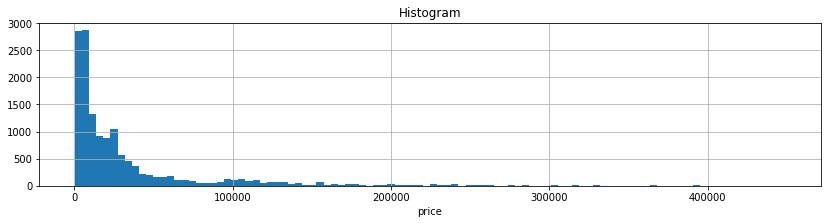

In [29]:
# Plot histogram of fare
df[df['currency'] == 'GBP'].price.hist(bins=100, figsize=(14,3))
plt.xlabel('price')
plt.title('Histogram')

#Values are in different currencies so we can not compare them


In [30]:
df['brand'].value_counts()

Cartier    181404
Name: brand, dtype: int64

## Small code to check if your dataframe has null values or empty values


In [31]:
import pandas as pd

# Example DataFrame (replace with your actual DataFrame)
# df = df_selected

# Check column data types
print("Column Data Types:")
print(df.dtypes)

# Check for null values
print("\nNull Values in Each Column:")
print(df.isnull().sum())

# Check for empty values (if cell has an empty string "")
print("\nEmpty String Values in Each Column:")
print((df == '').sum())

# Combine both: total nulls and empty values per column
print("\nTotal Null and Empty String Values per Column:")
print((df.isnull() | (df == '')).sum())


Column Data Types:
uid                       int32
brand                    object
url                      object
price                   float32
currency                 object
image_url                object
collection               object
reference_code           object
life_span_date           object
life_span                object
price_before            float32
price_difference          int32
price_percent_change    float32
price_changed           float32
dtype: object

Null Values in Each Column:
uid                         0
brand                       0
url                         0
price                   23730
currency                    0
image_url               21518
collection               8634
reference_code             30
life_span_date              0
life_span                   0
price_before            66552
price_difference            0
price_percent_change        0
price_changed               0
dtype: int64

Empty String Values in Each Column:
uid                 

In [33]:
df_pm = pd.read_csv('/Users/juandavidcasascano/Desktop/business_data_management/data/PM_TOTAL_12_2022.csv', on_bad_lines="skip")


In [34]:
df_pm.brand.value_counts()

Rolex                  336968
Omega                  232169
Cartier                181404
Louis Vuitton          174146
Blue Nile              145385
Longines               125830
Tudor                  104709
Breguet                 81221
Van Cleef & Arpels      80545
Hublot                  75858
Chopard                 65921
Chanel                  55061
Piaget                  53735
Bvlgari                 52576
Tiffany                 51670
Audemars Piguet         51140
Vacheron Constantin     50236
Dior                    44114
Patek Philippe          39652
Tag Heuer               39038
Boucheron               35273
Hermès                  28203
Zenith                  27153
IWC                     25742
Chaumet                 22790
Ulysse Nardin           22172
Girard-Perregaux        19997
Panerai                 18304
Jaeger-LeCoultre        14386
boucheron                7758
bvlgari                  3007
tiffany                  2482
dior                     1916
cartier   

## Script to create ficticious Sales

In [ ]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd
import random


In [ ]:

# Define project and dataset
project_id = "edhec-business-manageme"
dataset_id = "luxurydata2502"
price_table_id = "price-monitoring-2022"
sales_table_id = "fictitious-sales"

# Path to your service account key file
key_path = "/root/Business_data_management/Solution_Module_1/GCP_Keys/edhec-business-manageme-d72ddafc9d9a.json"

# Initialize BigQuery client
credentials = service_account.Credentials.from_service_account_file(key_path)
client = bigquery.Client(credentials=credentials, project=project_id)

# Define schema for the new table
sales_schema = [
    bigquery.SchemaField("reference_code", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("country", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("currency", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("number_of_items_sold", "INTEGER", mode="REQUIRED"),
    bigquery.SchemaField("total_sales", "FLOAT", mode="REQUIRED"),
    bigquery.SchemaField("year_of_sale", "INTEGER", mode="REQUIRED")
]

# Create the table
print(f"Creating table {sales_table_id} in dataset {dataset_id}...")
table_ref = client.dataset(dataset_id).table(sales_table_id)
table = bigquery.Table(table_ref, schema=sales_schema)
client.create_table(table, exists_ok=True)
print(f"Table {sales_table_id} created successfully.")

# Brand popularity mapping
brand_popularity = {
    "Rolex": 1000000, "Omega": 800000, "Cartier": 750000, "Louis Vuitton": 700000,
    "Blue Nile": 650000, "Longines": 600000, "Tudor": 550000, "Breguet": 500000,
    "Van Cleef & Arpels": 450000, "Hublot": 400000, "Chopard": 350000, "Chanel": 300000,
    "Piaget": 250000, "Bvlgari": 220000, "Tiffany": 200000, "Audemars Piguet": 150000,
    "Vacheron Constantin": 120000, "Dior": 100000, "Patek Philippe": 80000,
    "Tag Heuer": 75000, "Boucheron": 60000, "Hermès": 50000, "Zenith": 40000,
    "IWC": 35000, "Chaumet": 30000, "Ulysse Nardin": 25000, "Girard-Perregaux": 20000,
    "Panerai": 15000, "Jaeger-LeCoultre": 10000
}

# Adjust brand popularity for table
years = [2021, 2022, 2025]
sales_data = []

# Query to fetch only references from 2022
print("Fetching references from 2022 for brand sales data...")
query_2022 = f"""
    SELECT DISTINCT reference_code, brand, country, currency, price, EXTRACT(YEAR FROM life_span_date) AS year_of_sale
    FROM `{project_id}.{dataset_id}.{price_table_id}`
    WHERE price IS NOT NULL AND EXTRACT(YEAR FROM life_span_date) = 2022
"""

# Run the query and fetch results
query_job = client.query(query_2022)
rows = query_job.result()

# Collect all sales data into a list (to later create a DataFrame)
sales_records = []

# Process the data and populate the list
for row in rows:
    print(f"Processing reference code: {row.reference_code}, Brand: {row.brand}")
    
    if row.brand:  # Ensure brand is valid
        brand_sales_factor = brand_popularity.get(row.brand, 50000)
        
        # Generate sales data for other years using the same reference
        for year in years:
            # Only process 2021 and 2025 sales using data from 2022
            if year != 2022:
                mean_sales = brand_sales_factor // 1000  # Scale it down
                num_sold = random.gauss(mean_sales, mean_sales * 0.2)  # 20% variation from the mean
                num_sold = max(10, int(abs(num_sold)))  # Ensure non-negative sales volume
                
                # Calculate total sales
                total_sales = num_sold * row.price
                
                # Append to the sales records list
                sales_records.append({
                    "reference_code": row.reference_code,
                    "country": row.country,
                    "currency": row.currency,
                    "number_of_items_sold": num_sold,
                    "total_sales": total_sales,
                    "year_of_sale": year
                })

# Convert the sales records list to a DataFrame
df = pd.DataFrame(sales_records)

# Insert the data from the DataFrame into BigQuery
print(f"Inserting {len(df)} records into the sales table...")
client.load_table_from_dataframe(df, f"{project_id}.{dataset_id}.{sales_table_id}")

print("Fictitious sales data successfully inserted into the sales table.")


## Creating a simple price predict model

In [1]:
# Define project and dataset
project_id = "edhec-01"  # Replace with your project ID
dataset_id = "luxurydata2502"  # Replace with the name of the dataset you want to create
table_id = "price-monitoring-2022"
#key_path = "/Users/juandavidcasascano/Desktop/business_data_management/GCPkeys/edhec-01-39bece3963d5.json"  # Replace with the path to your key file

In [2]:
import pandas as pd 
import os
from pathlib import Path
#os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/Users/juandavidcasascano/Desktop/business_data_management/GCPkeys/edhec-01-39bece3963d5.json"


In [3]:
LOCAL_DATA_PATH = Path('~').joinpath("Desktop", "business_data_management", "data").expanduser()
GCP_PROJECT_EDHEC = project_id
BQ_DATASET = dataset_id
PROJECT_TABLE = "price-monitoring-2022"  
COLUMN_NAMES_RAW = ('uid', 'brand', 'url', 'price', 'currency', 'image_url', 'collection', 'reference_code', 'life_span_date', 'life_span', 
                    'price_before', 'price_difference', 'price_percent_change', 'price_changed')
BRAND = 'Vacheron Constantin'

In [4]:
data_query_cache_path = Path(LOCAL_DATA_PATH).joinpath(f"query_{BRAND}.csv")

In [5]:
query = f"""
    SELECT {",".join(COLUMN_NAMES_RAW)}
    FROM `{GCP_PROJECT_EDHEC}.{BQ_DATASET}.{PROJECT_TABLE}`
    WHERE brand = '{BRAND}'
    ORDER BY life_span_date DESC
    """
print(query)


    SELECT uid,brand,url,price,currency,image_url,collection,reference_code,life_span_date,life_span,price_before,price_difference,price_percent_change,price_changed
    FROM `edhec-01.luxurydata2502.price-monitoring-2022`
    WHERE brand = 'Cartier'
    ORDER BY life_span_date DESC
    


In [6]:
if data_query_cache_path.is_file():
    print("load local file...")
    df = pd.read_csv(data_query_cache_path, parse_dates=['life_span_date'])

else:
    print("Querying Big Query server...")
    from google.cloud import bigquery

    client = bigquery.Client(project=GCP_PROJECT_EDHEC)
    query_job = client.query(query)
    result = query_job.result()
    df = result.to_dataframe()

    df.to_csv(data_query_cache_path, header=True, index=False)


load local file...


In [7]:
df.head(2)

,uid,brand,url,price,currency,image_url,collection,reference_code,life_span_date,life_span,price_before,price_difference,price_percent_change,price_changed
0,3386766,Cartier,https://www.cartier.com/en-ae/watches/collecti...,14900.0,AED,https://www.cartier.com/dw/image/v2/BFHP_PRD/o...,"Panthère de Cartier watch, small model",WSPN0006,2022-12-28,Q4 December 2022,14900.0,0,0.0,0.0
1,3386767,Cartier,https://www.cartier.com/en-ae/watches/collecti...,16000.0,AED,https://www.cartier.com/dw/image/v2/BFHP_PRD/o...,Tank Must watch,WSTA0040,2022-12-28,Q4 December 2022,16000.0,0,0.0,0.0


In [8]:
df_cat = df[['brand', 'currency', 'collection', 'life_span']]
df_num = df['price']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [10]:
# Define the features and target variable
X = df_cat
y = df['price']

# Remove rows where the target variable is NaN or infinite
mask = ~np.isnan(y) & ~np.isinf(y)
X = X[mask]
y = y[mask]

# One-hot encode categorical variables
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
X_encoded = encoder.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)




In [11]:
# Define the model
model = KNeighborsRegressor(n_neighbors=5)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 382422573677237.25
R-squared: 0.44311779118054595
